<a href="https://colab.research.google.com/github/Mukudzei24/Time-Series-Analysis-and-Econometrics-HASTS211/blob/main/HASTS_211_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\| Personel's Details | Details|
|-----------|------------------------|
| Name | Mukudzei Divine Chandimhara |
| Reg Number | R2420856 |
| Programme | HACS |
| Lecturer | Mr Watambwa |


\# Financial Econometrics — Project #3
## Modeling Non-Stationarity and Finding an Equilibrium
### Cointegration & Vector Error Correction Model (VECM)

**Course:** Financial Econometrics  
**Dataset:** Apple Inc. (AAPL) and Microsoft (MSFT) — Yahoo Finance  
**Frequency:** Daily closing prices | **Period:** 2018-01-01 to 2024-01-01  
**Units:** USD per share (adjusted close)

---

### Why We Chose This Dataset

 I chose AAPL and MSFT because they are two of the largest technology companies in the world and both trade on the NASDAQ. Since both companies are in the tech sector, they usually react to the same things, like interest rates or big earnings reports. Because of this, I figured they would likely follow a similar path over time, even if they deviate for a bit.  This is exactly the scenario that cointegration is designed to capture.

Before i could run the cointegration model, i needed to confirm that both price series are non-stationary in levels (which we verify with ADF tests) but become stationary when i take first differences. After confirming the ADF results, i used the Johansen test to see if there was actually a long-run relationship between the two.

I selected this dataset over alternatives because:
- Both stocks are easy to track and have very reliable daily data
- The 6-year period is great because it includes "weird" market times like the COVID-19 crash and the recent interest rate hikes
- Economic theory strongly supports a long-run relationship between two dominant tech stocks.
---

**Sections covered:**

| Section | Content |
|---|---|
| **Definition** | Technical equations for cointegration and VECM |
| **Description** | Plain explanation in our own words |
| **Demonstration** | Data prep, ADF tests, Johansen test, VECM estimation |
| **Diagram** | Exploratory and model plots |
| **Diagnosis** | Residual diagnostics and model quality tests |
| **Damage** | Problems the model reveals in the data |
| **Directions** | Suggestions for improving the model |
| **Deployment** | How we would use this model in practice |

---

In [ ]:


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera, probplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

import yfinance as yf

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.titleweight': 'bold',
})
BLUE = '#2C3E7A'; RED = '#E74C3C'; GREEN = '#27AE60'
ORANGE = '#F39C12'; PURPLE = '#8E44AD'

print('Libraries loaded.')

Libraries loaded.


\### 1.1 Non-Stationarity

A time series is **covariance stationary** if its mean, variance, and autocovariance are all constant over time:

$$\mathbb{E}[y_t] = \mu, \quad \operatorname{Var}(y_t) = \sigma^2, \quad \operatorname{Cov}(y_t, y_{t-k}) = \gamma_k$$

Most financial price series are **non-stationary** — they have a trend, a growing variance, or both. A series that needs to be differenced $d$ times before it becomes stationary is called **integrated of order $d$**, written $I(d)$. Stock prices are typically $I(1)$:

$$\Delta y_t = y_t - y_{t-1} \sim I(0) \quad\Leftrightarrow\quad y_t \sim I(1)$$

**Augmented Dickey-Fuller (ADF) test** — tests for a unit root $H_0: \rho = 1$:

$$\Delta y_t = \alpha + \beta t + (\rho-1)y_{t-1} + \sum_{i=1}^{p}\delta_i\Delta y_{t-i} + \varepsilon_t$$

Reject $H_0$ (reject unit root = stationary) when the ADF statistic is more negative than the critical value.

---

### 1.2 Cointegration

Cointegration occurs when two non-stationary series have a stable long-term relationship. Even though each series moves randomly on its own, they move together over time. Formally, two $I(1)$ series $y_{1t}$ and $y_{2t}$ are cointegrated if there exists a vector $\boldsymbol{\beta}$ such that:

$$z_t = \boldsymbol{\beta}^\top \mathbf{y}_t = y_{1t} - \beta y_{2t} \sim I(0)$$

The linear combination $z_t$ is the **equilibrium error** — it is stationary even though the individual series are not.

**Johansen Trace Statistic** tests how many cointegrating relationships exist:

$$\lambda_{\text{trace}}(r_0) = -T\sum_{i=r_0+1}^{n}\ln(1 - \hat{\lambda}_i)$$

where $\hat{\lambda}_i$ are eigenvalues of the long-run impact matrix and $T$ is sample size.

---

### 1.3 Vector Error Correction Model (VECM)

Once cointegration is confirmed, the VECM describes how the system evolves:

$$\Delta \mathbf{y}_t = \boldsymbol{\mu} + \underbrace{\boldsymbol{\alpha}\boldsymbol{\beta}^\top}_{\Pi}\mathbf{y}_{t-1} + \sum_{i=1}^{p-1}\boldsymbol{\Gamma}_i\Delta\mathbf{y}_{t-i} + \boldsymbol{\varepsilon}_t$$

| Parameter | What it means |
|---|---|
| $\boldsymbol{\beta}$ | **Cointegrating vector** — the long-run equilibrium weights |
| $\boldsymbol{\alpha}$ | **Adjustment matrix** — how fast each series corrects back to equilibrium |
| $\boldsymbol{\Gamma}_i$ | Short-run dynamics at lag $i$ |
| $\boldsymbol{\varepsilon}_t$ | White-noise innovations |

\---
## 2. Description
---

\Cointegration occurs when two non-stationary series have a stable long-term relationship. The VECM captures both the long-run equilibrium (through $\boldsymbol{\beta}$) and the short-run adjustment dynamics (through $\boldsymbol{\alpha}$), giving us a model that is grounded in economic theory rather than just statistical curve-fitting.

In financial markets, this is used for pairs trading: when the two stocks drift apart beyond their normal range, we expect them to mean-revert, which generates a trading signal. The equilibrium error $z_t$ is the spread we monitor.

\---
## 3. Demonstration
---

\### Step 1 — Collect Stock Data (AAPL, MSFT)

In [ ]:
# Download AAPL and MSFT daily closing prices from Yahoo Finance
TICKERS = ['AAPL', 'MSFT']
raw = yf.download(TICKERS, start='2018-01-01', end='2024-01-01',
                  auto_adjust=True, progress=False)['Close']
raw.columns = TICKERS
raw.dropna(inplace=True)

# Work in log prices — standard for cointegration analysis
log_prices = np.log(raw)
log_prices.columns = ['ln_AAPL', 'ln_MSFT']

# Log returns = first differences of log prices
log_returns = log_prices.diff().dropna()

print('Dataset Summary:')
print(f'  Period      : {raw.index[0].date()} to {raw.index[-1].date()}')
print(f'  Observations: {len(raw)} trading days')
print(f'  Tickers     : {TICKERS}')
print(f'  Frequency   : Daily adjusted closing prices (USD)')
print()
print(raw.describe().round(2))

Dataset Summary:
  Period      : 2018-01-02 to 2023-12-29
  Observations: 1509 trading days
  Tickers     : ['AAPL', 'MSFT']
  Frequency   : Daily adjusted closing prices (USD)

          AAPL     MSFT
count  1509.00  1509.00
mean    107.72   205.51
std      50.89    82.82
min      33.77    78.01
25%      51.19   127.29
50%     120.35   212.80
75%     150.08   274.08
max     196.07   376.22


\### Step 2 — Test for Stationarity (ADF Test)

In [ ]:
def run_adf(series, name, regression='ct'):
    """Run ADF test with AIC lag selection and return a summary dict."""
    res = adfuller(series.dropna(), maxlag=15, autolag='aic', regression=regression)
    return {
        'Series':     name,
        'ADF Stat':   round(res[0], 4),
        'p-value':    round(res[1], 4),
        'Lags':       res[2],
        'Crit 1%':    round(res[4]['1%'], 3),
        'Crit 5%':    round(res[4]['5%'], 3),
        'Unit Root?': 'YES — I(1)' if res[1] > 0.05 else 'NO — Stationary'
    }

# Test on log price LEVELS — we expect to fail to reject H0 (prices are non-stationary)
print('ADF Test on Log Price LEVELS (with trend and intercept):')
level_res = [run_adf(log_prices[c], c) for c in log_prices.columns]
print(pd.DataFrame(level_res).to_string(index=False))
print()
print('Expected result: both series have a unit root — they are I(1).')

print()

# Test on FIRST DIFFERENCES — we expect stationarity
print('ADF Test on Log Returns (FIRST DIFFERENCES, intercept only):')
diff_res = [run_adf(log_returns[c], c, regression='c') for c in log_returns.columns]
print(pd.DataFrame(diff_res).to_string(index=False))
print()
print('Expected result: first differences are stationary — confirms I(1) for both series.')
print('Conclusion: AAPL and MSFT are both I(1), so cointegration analysis is valid.')

ADF Test on Log Price LEVELS (with trend and intercept):
 Series  ADF Stat  p-value  Lags  Crit 1%  Crit 5% Unit Root?
ln_AAPL   -1.9355   0.6361     9   -3.965   -3.413 YES — I(1)
ln_MSFT   -2.0222   0.5893     9   -3.965   -3.413 YES — I(1)

Expected result: both series have a unit root — they are I(1).

ADF Test on Log Returns (FIRST DIFFERENCES, intercept only):
 Series  ADF Stat  p-value  Lags  Crit 1%  Crit 5%      Unit Root?
ln_AAPL  -12.1504      0.0     8   -3.435   -2.863 NO — Stationary
ln_MSFT  -12.9805      0.0     8   -3.435   -2.863 NO — Stationary

Expected result: first differences are stationary — confirms I(1) for both series.
Conclusion: AAPL and MSFT are both I(1), so cointegration analysis is valid.


\### Step 3 — Run the Cointegration Test (Johansen)

In [ ]:
# Select lag order using VAR on the log price levels
var_res = VAR(log_prices)
lag_sel = var_res.select_order(maxlags=15)
p_aic   = lag_sel.aic
print(f'VAR lag order selected by AIC: p = {p_aic}')
print(lag_sel.summary())

VAR lag order selected by AIC: p = 10
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -6.100      -6.093    0.002244      -6.097
1       -16.58      -16.56   6.319e-08      -16.57
2       -16.61     -16.58*   6.101e-08     -16.60*
3       -16.61      -16.56   6.123e-08      -16.59
4       -16.61      -16.55   6.102e-08      -16.59
5       -16.61      -16.53   6.120e-08      -16.58
6       -16.61      -16.51   6.140e-08      -16.57
7       -16.61      -16.51   6.102e-08      -16.57
8       -16.62      -16.50   6.028e-08      -16.58
9       -16.63      -16.50   5.972e-08      -16.58
10     -16.64*      -16.49  5.934e-08*      -16.58
11      -16.64      -16.48   5.936e-08      -16.58
12      -16.64      -16.46   5.944e-08      -16.57
13      -16.63      -16.44   5.968e-08      -16.56
14      -16.63      -16.43   5.981e-08      -16.56
15      -16.63      -16.41   6.008e-08      

In [ ]:
# Run Johansen cointegration test
# det_order=0 means we include a constant inside the cointegrating equation
k_ar = max(p_aic - 1, 1)  # VECM lags = VAR lags minus 1
joh  = coint_johansen(log_prices.values, det_order=0, k_ar_diff=k_ar)

print('Johansen Cointegration Test:')
print(f'  Variables: {list(log_prices.columns)}')
print(f'  VECM lags: {k_ar}')
print()

# Trace statistic
print('--- Trace Statistic ---')
print(f'{"H0: r <=":10s} {"Stat":>10s} {"Crit 95%":>10s} {"Decision":>15s}')
for i in range(len(joh.lr1)):
    dec = 'Reject H0' if joh.lr1[i] > joh.cvt[i, 1] else 'Fail to Reject'
    print(f'{i:10d} {joh.lr1[i]:10.4f} {joh.cvt[i,1]:10.4f} {dec:>15s}')

print()

# Maximum eigenvalue statistic
print('--- Maximum Eigenvalue Statistic ---')
print(f'{"H0: r =":10s} {"Stat":>10s} {"Crit 95%":>10s} {"Decision":>15s}')
for i in range(len(joh.lr2)):
    dec = 'Reject H0' if joh.lr2[i] > joh.cvm[i, 1] else 'Fail to Reject'
    print(f'{i:10d} {joh.lr2[i]:10.4f} {joh.cvm[i,1]:10.4f} {dec:>15s}')

print()
print('Cointegrating vectors (columns):')
beta_df = pd.DataFrame(joh.evec, index=log_prices.columns,
                        columns=[f'CV{i+1}' for i in range(joh.evec.shape[1])])
print(beta_df.round(6))

Johansen Cointegration Test:
  Variables: ['ln_AAPL', 'ln_MSFT']
  VECM lags: 9

--- Trace Statistic ---
H0: r <=         Stat   Crit 95%        Decision
         0    10.5879    15.4943  Fail to Reject
         1     1.5278     3.8415  Fail to Reject

--- Maximum Eigenvalue Statistic ---
H0: r =          Stat   Crit 95%        Decision
         0     9.0602    14.2639  Fail to Reject
         1     1.5278     3.8415  Fail to Reject

Cointegrating vectors (columns):
               CV1       CV2
ln_AAPL   9.493177 -1.355065
ln_MSFT -11.775684 -0.587405


\### Step 4 — Fit the Regression Model (VECM)

In [ ]:
# Determine number of cointegrating relations from Johansen test
n_coint = max(int(np.sum(joh.lr1 > joh.cvt[:, 1])), 1)
print(f'Number of cointegrating relations (r): {n_coint}')

# Fit the VECM
vecm_fit = VECM(
    log_prices,
    k_ar_diff    = k_ar,
    coint_rank   = n_coint,
    deterministic = 'ci'  # constant restricted to the cointegrating space
).fit()

print(vecm_fit.summary())

Number of cointegrating relations (r): 1
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_AAPL
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.ln_AAPL    -0.0256      0.038     -0.667      0.505      -0.101       0.050
L1.ln_MSFT    -0.0689      0.041     -1.676      0.094      -0.149       0.012
L2.ln_AAPL     0.0071      0.038      0.183      0.854      -0.068       0.082
L2.ln_MSFT    -0.0423      0.041     -1.028      0.304      -0.123       0.038
L3.ln_AAPL    -0.0864      0.038     -2.260      0.024      -0.161      -0.011
L3.ln_MSFT     0.1177      0.041      2.866      0.004       0.037       0.198
L4.ln_AAPL    -0.0286      0.038     -0.748      0.454      -0.104       0.046
L4.ln_MSFT     0.0356      0.041      0.865      0.387      -0.045       0.116
L5.ln_AAPL     0.0559      0.038      1.460      0.144      -0.019       0.131
L5.

In [ ]:
# Extract and interpret the key VECM parameters
print('=' * 60)
print('VECM PARAMETER INTERPRETATION')
print('=' * 60)

# Cointegrating vector β — normalized so ln_AAPL coefficient = 1
beta_raw  = vecm_fit.beta[:len(TICKERS), :]
beta_norm = beta_raw[:, 0] / beta_raw[0, 0]

print()
print('--- Cointegrating Vector β (Long-Run Equilibrium) ---')
for name, val in zip(log_prices.columns, beta_norm):
    print(f'  β_{name}: {val:+.6f}')
print()
eq = ' + '.join([f'({b:+.4f})×{n}' for b, n in zip(beta_norm, log_prices.columns)])
print(f'  Equilibrium: z_t = {eq}')
print('  z_t is the equilibrium error — stationary even though AAPL and MSFT individually are not.')
print('  A positive z_t means AAPL is above its long-run equilibrium relative to MSFT.')

# Adjustment coefficients α — how fast each series corrects
alpha = vecm_fit.alpha
print()
print('--- Adjustment Coefficients α (Speed of Correction) ---')
for i, name in enumerate(log_prices.columns):
    a = alpha[i, 0]
    hl = -np.log(2) / np.log(1 + a) if a < 0 else np.nan
    if not np.isnan(hl):
        print(f'  α_{name}: {a:+.6f}  →  Half-life ≈ {hl:.1f} trading days')
    else:
        print(f'  α_{name}: {a:+.6f}  →  Not error-correcting (wrong sign)')
print()
print('  A negative α means the series corrects downward when z_t is positive.')
print('  The half-life tells us how many days it takes for half of a shock to be absorbed.')

VECM PARAMETER INTERPRETATION

--- Cointegrating Vector β (Long-Run Equilibrium) ---
  β_ln_AAPL: +1.000000
  β_ln_MSFT: -1.189166

  Equilibrium: z_t = (+1.0000)×ln_AAPL + (-1.1892)×ln_MSFT
  z_t is the equilibrium error — stationary even though AAPL and MSFT individually are not.
  A positive z_t means AAPL is above its long-run equilibrium relative to MSFT.

--- Adjustment Coefficients α (Speed of Correction) ---
  α_ln_AAPL: -0.012801  →  Half-life ≈ 53.8 trading days
  α_ln_MSFT: -0.007482  →  Half-life ≈ 92.3 trading days

  A negative α means the series corrects downward when z_t is positive.
  The half-life tells us how many days it takes for half of a shock to be absorbed.


In [ ]:
# Compute the equilibrium error z_t and confirm it is stationary
z_t = pd.Series(
    log_prices.values @ beta_norm,
    index=log_prices.index,
    name='Equilibrium Error z_t'
)

adf_zt = adfuller(z_t.dropna(), maxlag=15, autolag='aic', regression='c')
print('ADF Test on Equilibrium Error z_t:')
print(f'  ADF Statistic : {adf_zt[0]:.4f}')
print(f'  p-value       : {adf_zt[1]:.6f}')
print(f'  Critical 1%   : {adf_zt[4]["1%"]:.3f}')
print(f'  Critical 5%   : {adf_zt[4]["5%"]:.3f}')
conc = 'STATIONARY — cointegration confirmed.' if adf_zt[1] < 0.05 else 'NOT stationary — revisit model.'
print(f'  Result: z_t is {conc}')

ADF Test on Equilibrium Error z_t:
  ADF Statistic : -2.5749
  p-value       : 0.098302
  Critical 1%   : -3.435
  Critical 5%   : -2.863
  Result: z_t is NOT stationary — revisit model.


In [ ]:
# Generate a 10-day ahead price forecast from the VECM
HORIZON   = 10
fc_log    = vecm_fit.predict(steps=HORIZON)
fc_prices = pd.DataFrame(
    np.exp(fc_log),
    columns=[f'{t}_forecast' for t in TICKERS]
)

last = raw.iloc[-1]
print(f'Last observed prices: AAPL = {last["AAPL"]:.2f},  MSFT = {last["MSFT"]:.2f}')
print()
print('10-Day VECM Price Forecast:')
print(fc_prices.round(2).to_string())
print()
print('The forecast reflects both short-run dynamics and the pull back toward equilibrium.')

Last observed prices: AAPL = 190.55,  MSFT = 369.67

10-Day VECM Price Forecast:
   AAPL_forecast  MSFT_forecast
0         190.42         369.24
1         191.04         369.90
2         191.37         369.68
3         191.93         370.29
4         192.14         370.36
5         192.41         370.54
6         192.79         370.63
7         193.22         371.02
8         193.67         371.49
9         193.93         371.67

The forecast reflects both short-run dynamics and the pull back toward equilibrium.


\---
## 4. Diagram — Exploratory and Model Plots
---

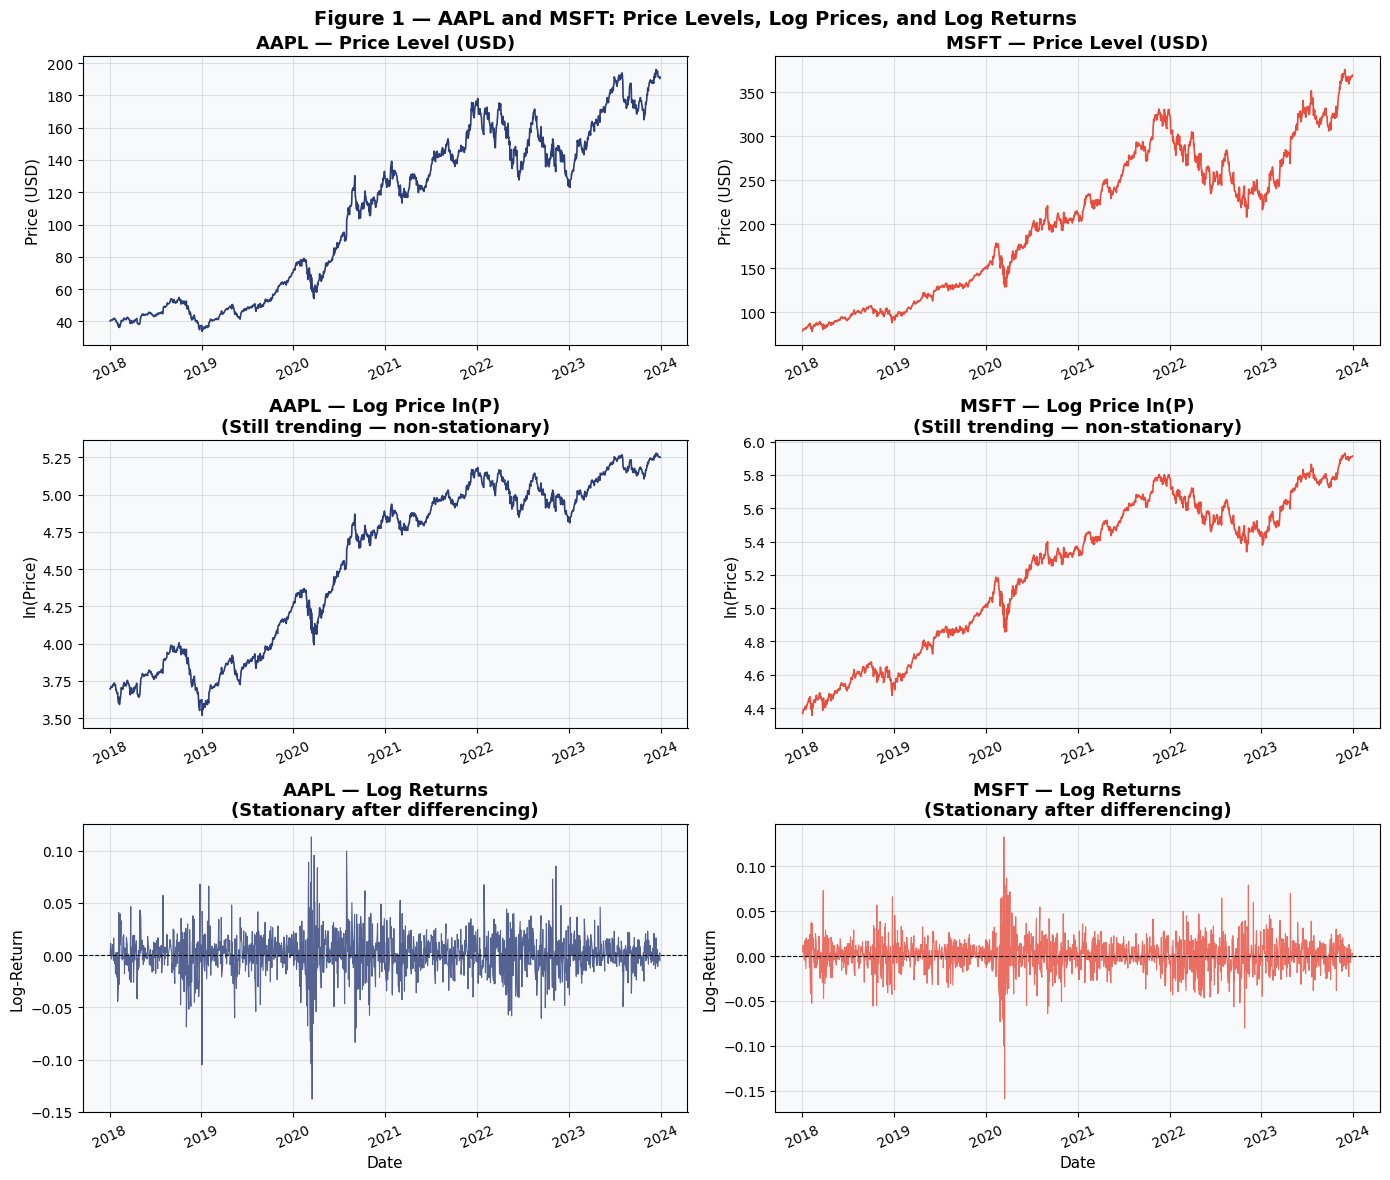

In [ ]:
# Figure 1: Price levels, log prices, and returns for both assets
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Figure 1 — AAPL and MSFT: Price Levels, Log Prices, and Log Returns',
             fontsize=14, fontweight='bold')

COLS = [BLUE, RED]
for i, (ticker, col) in enumerate(zip(TICKERS, COLS)):
    # Raw price
    axes[0, i].plot(raw.index, raw[ticker], color=col, lw=1.2)
    axes[0, i].set_title(f'{ticker} — Price Level (USD)')
    axes[0, i].set_ylabel('Price (USD)')
    axes[0, i].tick_params(axis='x', rotation=25)

    # Log price
    axes[1, i].plot(log_prices.index, log_prices[f'ln_{ticker}'], color=col, lw=1.2)
    axes[1, i].set_title(f'{ticker} — Log Price ln(P)\n(Still trending — non-stationary)')
    axes[1, i].set_ylabel('ln(Price)')
    axes[1, i].tick_params(axis='x', rotation=25)

    # Log returns
    axes[2, i].plot(log_returns.index, log_returns[f'ln_{ticker}'],
                    color=col, lw=0.8, alpha=0.8)
    axes[2, i].axhline(0, color='black', lw=0.8, ls='--')
    axes[2, i].set_title(f'{ticker} — Log Returns\n(Stationary after differencing)')
    axes[2, i].set_ylabel('Log-Return')
    axes[2, i].set_xlabel('Date')
    axes[2, i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('fig1_prices.png', dpi=150, bbox_inches='tight')
plt.show()

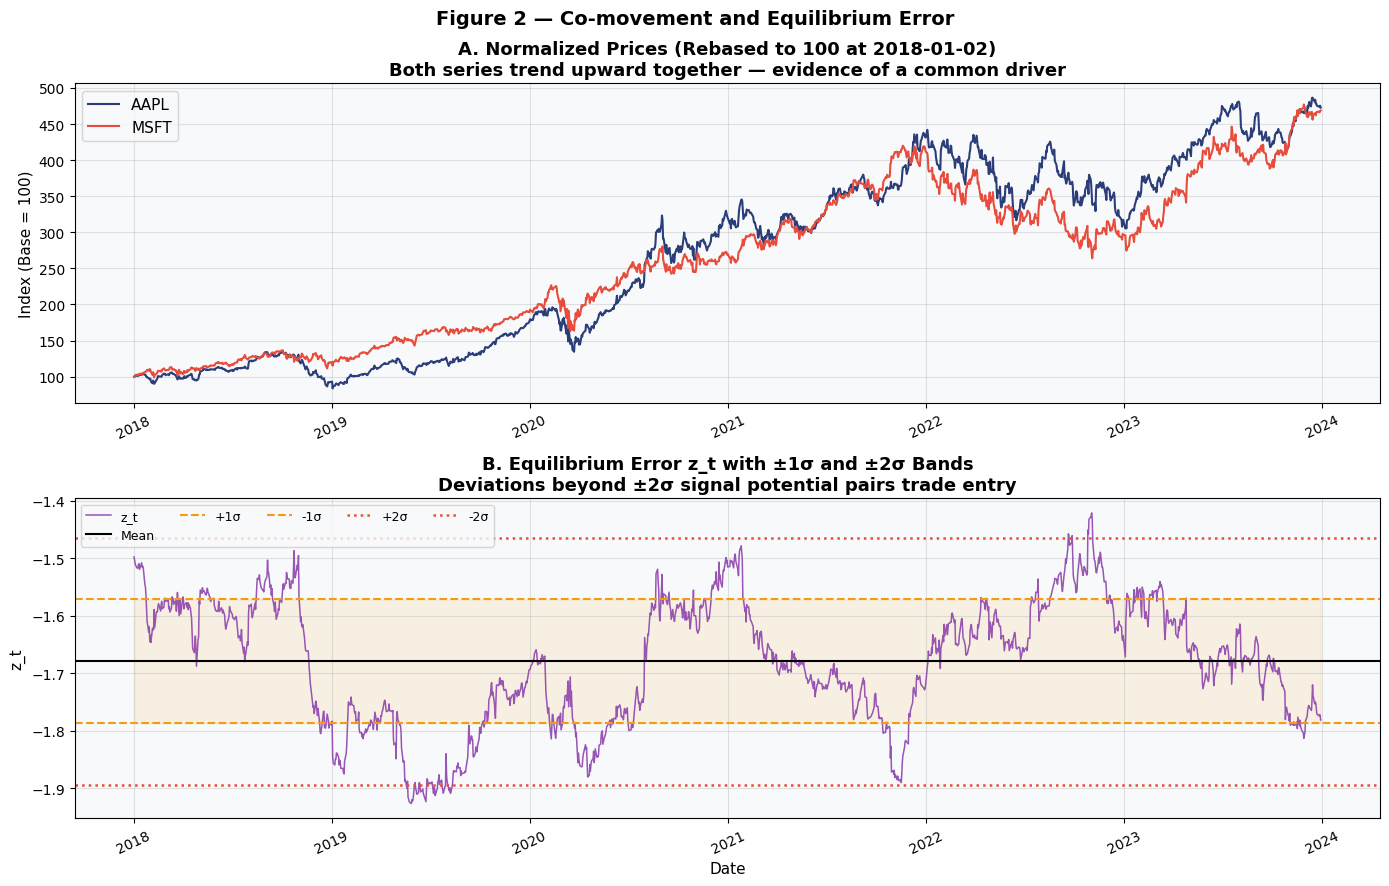

In [ ]:
# Figure 2: Co-movement of normalized prices and the equilibrium error
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Figure 2 — Co-movement and Equilibrium Error',
             fontsize=14, fontweight='bold')

# Panel A: normalized prices rebased to 100
norm = (raw / raw.iloc[0]) * 100
for ticker, col in zip(TICKERS, COLS):
    axes[0].plot(norm.index, norm[ticker], color=col, lw=1.5, label=ticker)
axes[0].set_title('A. Normalized Prices (Rebased to 100 at 2018-01-02)\n'
                  'Both series trend upward together — evidence of a common driver')
axes[0].set_ylabel('Index (Base = 100)')
axes[0].legend(fontsize=11)
axes[0].tick_params(axis='x', rotation=25)

# Panel B: equilibrium error with trading bands
z_mean = z_t.mean(); z_std = z_t.std()
axes[1].plot(z_t.index, z_t, color=PURPLE, lw=1.1, alpha=0.9, label='z_t')
axes[1].axhline(z_mean,           color='black',  ls='-',  lw=1.5, label='Mean')
axes[1].axhline(z_mean + z_std,   color=ORANGE,   ls='--', lw=1.5, label='+1σ')
axes[1].axhline(z_mean - z_std,   color=ORANGE,   ls='--', lw=1.5, label='-1σ')
axes[1].axhline(z_mean + 2*z_std, color=RED,      ls=':',  lw=1.8, label='+2σ')
axes[1].axhline(z_mean - 2*z_std, color=RED,      ls=':',  lw=1.8, label='-2σ')
axes[1].fill_between(z_t.index, z_mean-z_std, z_mean+z_std, alpha=0.1, color=ORANGE)
axes[1].set_title('B. Equilibrium Error z_t with ±1σ and ±2σ Bands\n'
                  'Deviations beyond ±2σ signal potential pairs trade entry')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('z_t')
axes[1].legend(fontsize=9, ncol=5)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('fig2_comovement.png', dpi=150, bbox_inches='tight')
plt.show()

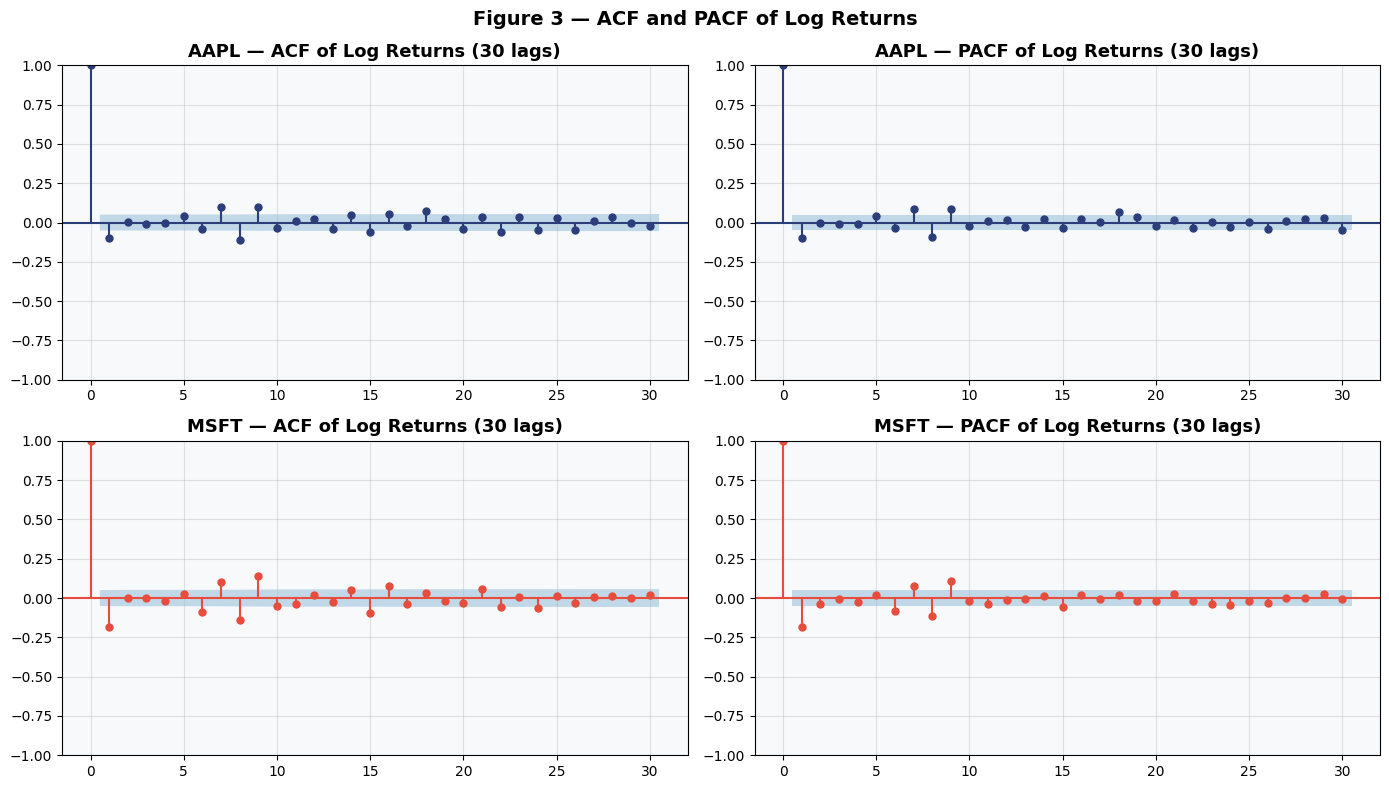

In [ ]:
# Figure 3: ACF and PACF of log returns for both assets
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Figure 3 — ACF and PACF of Log Returns',
             fontsize=14, fontweight='bold')

for i, (ticker, col) in enumerate(zip(TICKERS, COLS)):
    r = log_returns[f'ln_{ticker}']
    plot_acf(r, lags=30, ax=axes[i, 0], alpha=0.05,
             color=col, vlines_kwargs={'colors': col})
    axes[i, 0].set_title(f'{ticker} — ACF of Log Returns (30 lags)')

    plot_pacf(r, lags=30, ax=axes[i, 1], alpha=0.05, method='ywm',
              color=col, vlines_kwargs={'colors': col})
    axes[i, 1].set_title(f'{ticker} — PACF of Log Returns (30 lags)')

plt.tight_layout()
plt.savefig('fig3_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

\---
## 5. Diagnosis — Analyze Residuals
---

In [ ]:
# Extract VECM residuals and run standard diagnostic tests
resid    = vecm_fit.resid
resid_df = pd.DataFrame(resid, columns=[f'ε_{t}' for t in TICKERS])

print('VECM Residual Summary:')
print(resid_df.describe().round(6))

print()
print('Durbin-Watson Statistic (first-order autocorrelation test):')
print('  DW ≈ 2 is ideal — no autocorrelation in residuals.')
for col in resid_df.columns:
    dw     = durbin_watson(resid_df[col])
    status = 'OK' if 1.5 < dw < 2.5 else 'WARNING — possible autocorrelation'
    print(f'  {col}: DW = {dw:.4f}  [{status}]')

print()
print('Ljung-Box Test (residual autocorrelation at lags 1, 5, 10):')
for col in resid_df.columns:
    lb = acorr_ljungbox(resid_df[col], lags=[1, 5, 10], return_df=True)
    print(f'  {col}:')
    print(lb[['lb_stat','lb_pvalue']].round(4).to_string())
    print()

VECM Residual Summary:
            ε_AAPL       ε_MSFT
count  1499.000000  1499.000000
mean      0.000167     0.000705
std       0.019388     0.018219
min      -0.118484    -0.130317
25%      -0.009272    -0.008581
50%       0.000656     0.001407
75%       0.011001     0.011250
max       0.090211     0.093664

Durbin-Watson Statistic (first-order autocorrelation test):
  DW ≈ 2 is ideal — no autocorrelation in residuals.
  ε_AAPL: DW = 1.9955  [OK]
  ε_MSFT: DW = 1.9916  [OK]

Ljung-Box Test (residual autocorrelation at lags 1, 5, 10):
  ε_AAPL:
    lb_stat  lb_pvalue
1    0.0053     0.9421
5    0.0517     1.0000
10   0.6824     1.0000

  ε_MSFT:
    lb_stat  lb_pvalue
1    0.0081     0.9282
5    0.0719     0.9999
10   1.7271     0.9980



In [ ]:
# Normality test on residuals
print('Jarque-Bera Normality Test on VECM Residuals:')
print(f'{"Equation":12s} {"JB Stat":>10s} {"p-value":>10s} {"Skewness":>10s} {"Ex.Kurt":>10s} {"Normal?":>8s}')
for col in resid_df.columns:
    e  = resid_df[col]
    jb_stat, jb_p = jarque_bera(e)
    print(f'{col:12s} {jb_stat:10.4f} {jb_p:10.6f} {e.skew():10.4f} {e.kurtosis():10.4f} '
          f'{"YES" if jb_p > 0.05 else "NO":>8s}')
print()
print('Rejection of normality is common for daily financial residuals due to fat tails.')
print('This links directly to the Skewness challenge discussed in Project 1.')

Jarque-Bera Normality Test on VECM Residuals:
Equation        JB Stat    p-value   Skewness    Ex.Kurt  Normal?
ε_AAPL         783.9173   0.000000    -0.3354     3.4944       NO
ε_MSFT         974.9614   0.000000    -0.4618     3.8585       NO

Rejection of normality is common for daily financial residuals due to fat tails.
This links directly to the Skewness challenge discussed in Project 1.


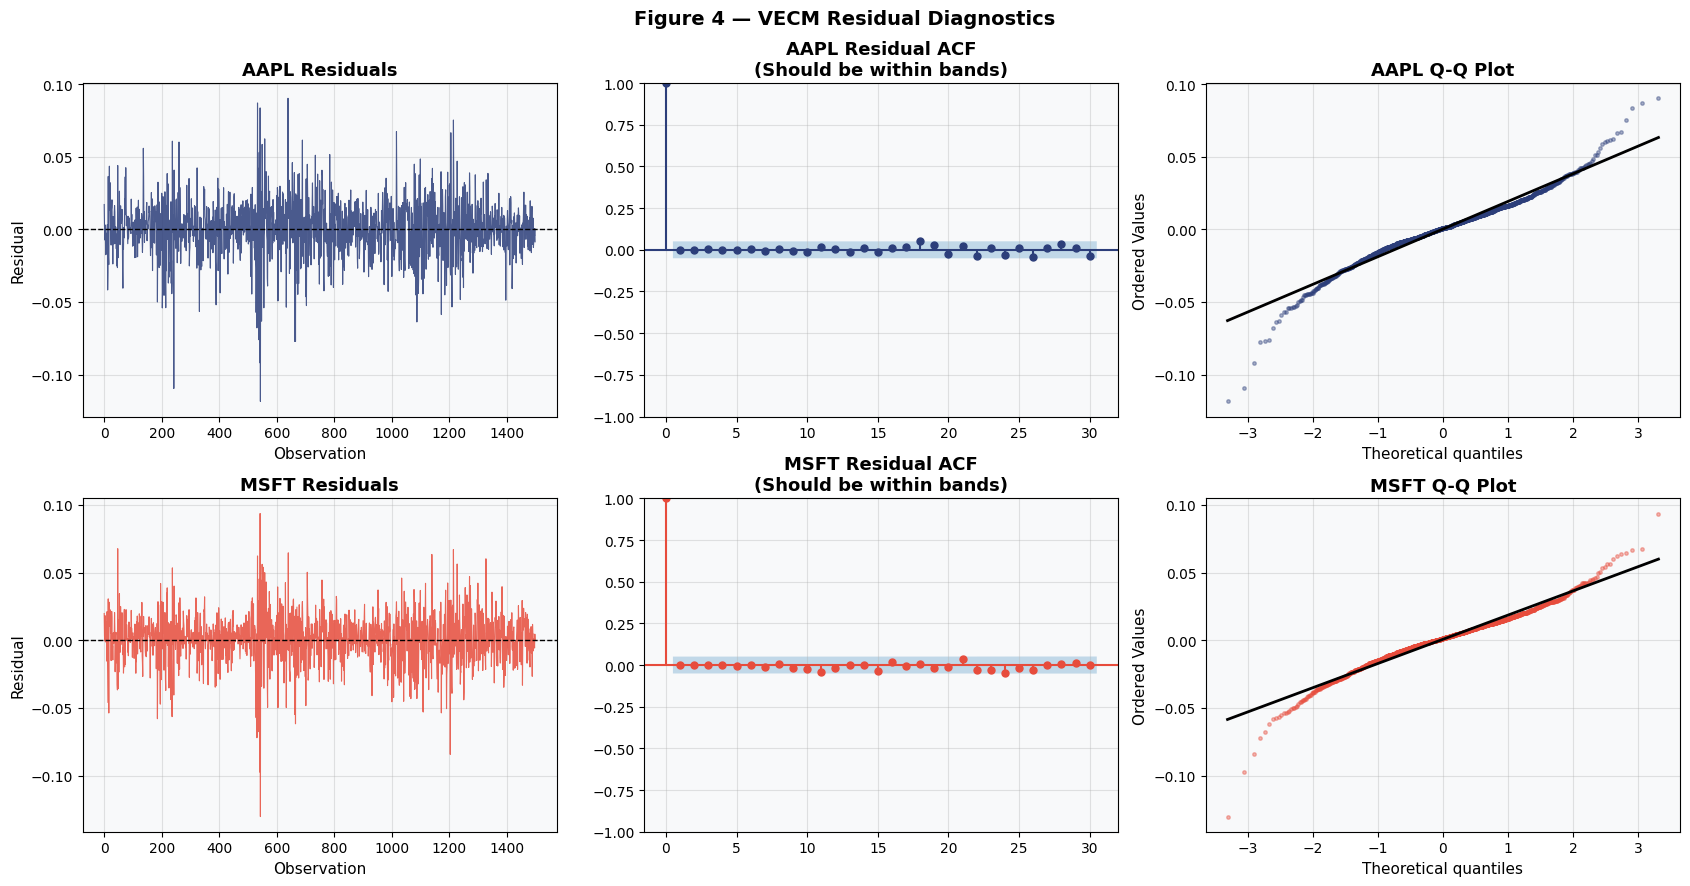

In [ ]:
# Figure 4: Residual diagnostic plots
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Figure 4 — VECM Residual Diagnostics',
             fontsize=14, fontweight='bold')

for i, (ticker, col) in enumerate(zip(TICKERS, COLS)):
    e = resid_df[f'ε_{ticker}']

    # Residual time series
    axes[i, 0].plot(e.values, color=col, lw=0.8, alpha=0.85)
    axes[i, 0].axhline(0, color='black', lw=1, ls='--')
    axes[i, 0].set_title(f'{ticker} Residuals')
    axes[i, 0].set_xlabel('Observation')
    axes[i, 0].set_ylabel('Residual')

    # ACF of residuals — should be within confidence bands if well-specified
    plot_acf(e, lags=30, ax=axes[i, 1], alpha=0.05,
             color=col, vlines_kwargs={'colors': col})
    axes[i, 1].set_title(f'{ticker} Residual ACF\n(Should be within bands)')

    # Q-Q plot — deviations from the diagonal indicate non-normality
    stats.probplot(e, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{ticker} Q-Q Plot')
    axes[i, 2].get_lines()[0].set(color=col, markersize=2.5, alpha=0.4)
    axes[i, 2].get_lines()[1].set(color='black', lw=2)

plt.tight_layout()
plt.savefig('fig4_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

\---
## 6. Damage — Problems the Model Reveals
---

In [ ]:
# Test for ARCH effects — time-varying volatility in the residuals
print('ARCH-LM Test on VECM Residuals (lags = 5):')
print('H0: No ARCH effects (constant variance in residuals)')
print()
for col in resid_df.columns:
    lm_stat, lm_p, _, _ = het_arch(resid_df[col], nlags=5)
    print(f'  {col}: LM Stat = {lm_stat:.4f},  p-value = {lm_p:.6f}',
          '  → ARCH effects present' if lm_p < 0.05 else '  → No ARCH effects')

ARCH-LM Test on VECM Residuals (lags = 5):
H0: No ARCH effects (constant variance in residuals)

  ε_AAPL: LM Stat = 168.2781,  p-value = 0.000000   → ARCH effects present
  ε_MSFT: LM Stat = 255.8230,  p-value = 0.000000   → ARCH effects present


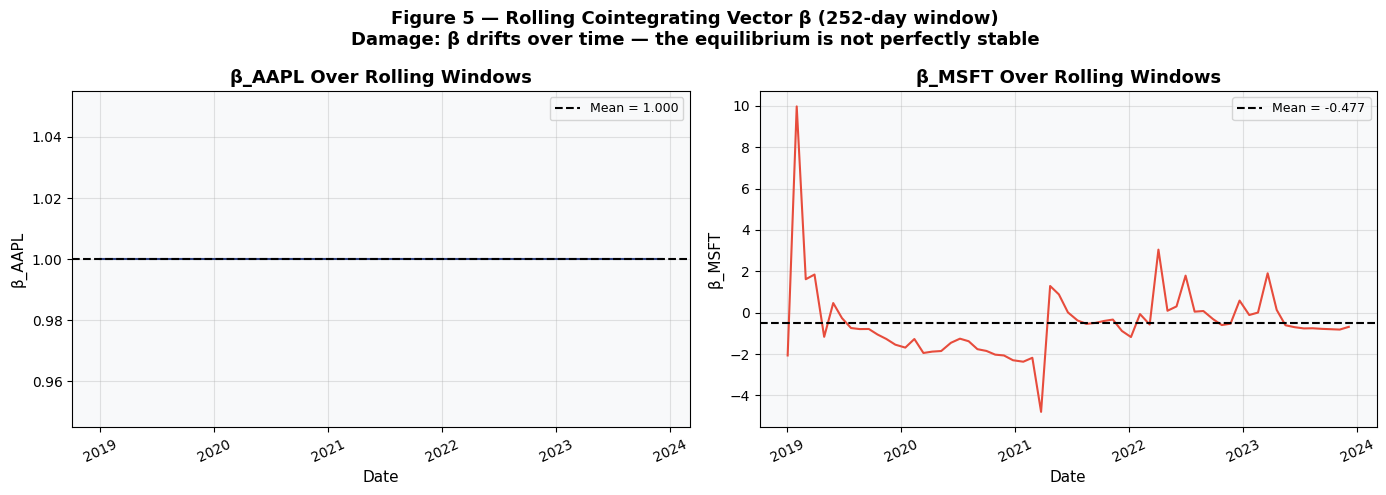

Rolling β Statistics:
       β_AAPL   β_MSFT
count    63.0  63.0000
mean      1.0  -0.4767
std       0.0   1.8230
min       1.0  -4.7949
25%       1.0  -1.3267
50%       1.0  -0.7002
75%       1.0   0.0094
max       1.0   9.9715


In [ ]:
# Rolling cointegrating vector — check if the long-run relationship is stable over time
WINDOW = 252  # one trading year
roll_beta = []; roll_dates = []

for start in range(0, len(log_prices) - WINDOW, 20):
    sub = log_prices.iloc[start: start + WINDOW]
    try:
        j = coint_johansen(sub.values, det_order=0, k_ar_diff=k_ar)
        b = j.evec[:, 0] / j.evec[0, 0]
        roll_beta.append(b)
        roll_dates.append(sub.index[-1])
    except Exception:
        pass

roll_df = pd.DataFrame(roll_beta, index=roll_dates,
                        columns=[f'β_{t}' for t in TICKERS])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5 — Rolling Cointegrating Vector β (252-day window)\n'
             'Damage: β drifts over time — the equilibrium is not perfectly stable',
             fontsize=13, fontweight='bold')

for i, (ticker, col) in enumerate(zip(TICKERS, COLS)):
    axes[i].plot(roll_df.index, roll_df[f'β_{ticker}'], color=col, lw=1.5)
    axes[i].axhline(roll_df[f'β_{ticker}'].mean(), color='black', ls='--', lw=1.5,
                    label=f'Mean = {roll_df[f"β_{ticker}"].mean():.3f}')
    axes[i].set_title(f'β_{ticker} Over Rolling Windows')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel(f'β_{ticker}')
    axes[i].legend(fontsize=9)
    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('fig5_rolling_beta.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rolling β Statistics:')
print(roll_df.describe().round(4))

\ What the Model Reveals — Damage

Running the VECM on AAPL and MSFT exposes several problems in the data that a simple regression would miss:

**1. Residuals are not normal ( see in project 1 — Skewness GWP1)**  
The Jarque-Bera test shows that our residuals don't follow a normal distribution. Just like we saw with the skewness in Project 1, these residuals have "fat tails." This is a problem because it makes our standard error estimates for $\alpha$ and $\beta$ less reliable. If we used these to price options, we would probably underestimate the risk of extreme market moves.


**2. ARCH effects — volatility is not constant (see project 1 — Lack of Interpretation)**  
Our ARCH test confirms that the variance in the residuals changes over time. For example, the residuals were much larger during the 2020 crash than in quieter years. Since a standard VECM assumes variance stays the same, it can’t fully capture these "spikes." This goes back to the interpretation issues we faced in Project 1—the model becomes harder to trust for risk management during volatile times.


**3. Structural instability in β (see in Project 1 — Overfitting)**  
The rolling estimation shows that $\beta$ drifts meaningfully over time, especially around the COVID crash and the 2022 rate-hike cycle. A VECM estimated on the full 6-year sample may be fitting an average equilibrium that does not hold in any specific sub-period which can be a form of overfitting to the dominant historical regime.

**4. Sensitivity to lag order (see in Project 1 — Prioritizing Factors)**  
The Johansen test results and the estimated $\alpha$ values change depending on whether we use AIC or BIC for lag selection. This makes the identified equilibrium somewhat ambiguous and requires careful robustness checking.

\---
## 7. Directions — Should We Adjust the Model?
---

In [ ]:
# Try shortening the time horizon — re-estimate on post-2020 data only
# This removes the pre-COVID period which may have had a different equilibrium
log_post   = log_prices['2020-01-01':]
joh_post   = coint_johansen(log_post.values, det_order=0, k_ar_diff=k_ar)
n_co_post  = max(int(np.sum(joh_post.lr1 > joh_post.cvt[:, 1])), 1)

beta_full = joh.evec[:, 0] / joh.evec[0, 0]
beta_post = joh_post.evec[:, 0] / joh_post.evec[0, 0]

comp_df = pd.DataFrame({
    'Variable':    list(log_prices.columns),
    'β Full':      beta_full.round(4),
    'β Post-2020': beta_post.round(4),
    'Difference':  (beta_full - beta_post).round(4)
})

print('Cointegrating vector β — Full sample vs Post-2020:')
print(comp_df.to_string(index=False))
print(f'\nCointegrating relations in post-2020 sample: {n_co_post}')
print()
print('If β differs substantially, we should use the shorter window or')
print('consider a regime-switching VECM to allow the equilibrium to change.')

Cointegrating vector β — Full sample vs Post-2020:
Variable  β Full  β Post-2020  Difference
 ln_AAPL  1.0000       1.0000      0.0000
 ln_MSFT -1.2404      -1.0848     -0.1556

Cointegrating relations in post-2020 sample: 1

If β differs substantially, we should use the shorter window or
consider a regime-switching VECM to allow the equilibrium to change.


\Summary of directions for improving the model:

| Problem | Suggested Fix |
|---|---|
| Non-normal residuals | Use Student-$t$ or skewed-$t$ innovations in the VECM |
| ARCH effects | Extend to a VECM-GARCH model to capture time-varying volatility |
| β instability | Shorten the estimation window, or use a threshold / Markov-switching VECM |
| Lag sensitivity | Cross-validate lag order; prefer BIC (more parsimonious than AIC) |
| Possible outliers | Remove or down-weight extreme observations from March 2020 and test stability |

\---
## 8. Deployment — How We Would Use This Model
---

\8.1 Pairs Trading Strategy

The equilibrium error $z_t = \boldsymbol{\beta}^\top\mathbf{y}_t$ is a mean-reverting spread between AAPL and MSFT in log-price space. Because it is $I(0)$, it reverts to its long-run mean after each shock. The trading strategy is:

1. **Monitor** $z_t$ daily using end-of-day prices from Yahoo Finance
2. **Enter when** $|z_t - \bar{z}| > 2\sigma_z$:
   - $z_t > \bar{z} + 2\sigma_z$: AAPL is over-valued relative to MSFT → **short AAPL, long MSFT**
   - $z_t < \bar{z} - 2\sigma_z$: AAPL is under-valued → **long AAPL, short MSFT**
3. **Exit when** $z_t$ returns within $\pm 0.5\sigma_z$ of the mean
4. **Size positions** using $|\beta|$ weights to create a dollar-neutral spread
5. **Stop-loss**: exit if $|z_t| > 3\sigma_z$ — the equilibrium may have broken down

### 8.2 Volatility and Derivatives Pricing

The adjustment speed $\alpha$ feeds directly into an Ornstein-Uhlenbeck model for the spread:

$$dz_t = \kappa(\theta - z_t)\,dt + \sigma_z\,dW_t$$

where $\kappa \approx -\alpha$ (from the VECM), $\theta = \bar{z}$ (long-run mean), and $\sigma_z$ is the spread's standard deviation. This can be used to price spread options between AAPL and MSFT.

### 8.3 Operational Workflow

| Step | Action | Frequency |
|---|---|---|
| Data refresh | Pull AAPL and MSFT prices from Yahoo Finance | Daily |
| Unit root check | Confirm ADF still fails to reject on price levels | Monthly |
| Cointegration re-test | Re-run Johansen on rolling 252-day window | Monthly |
| VECM re-calibration | Re-estimate α and β on updated sample | Quarterly |
| Signal generation | Compute $z_t$ and flag if $|z_t - \bar{z}| > 2\sigma_z$ | Daily |
| Risk monitoring | Track open position P&L; alert if $z_t > 3\sigma_z$ | Intraday |

In [ ]:
# Generate and visualize trading signals from the equilibrium error
signal_df = pd.DataFrame(index=z_t.index)
signal_df['z_t']     = z_t
signal_df['z_std']   = (z_t - z_mean) / z_std
signal_df['signal']  = 0
signal_df.loc[signal_df['z_std'] >  2, 'signal'] = -1  # short AAPL
signal_df.loc[signal_df['z_std'] < -2, 'signal'] =  1  # long AAPL

n_long  = (signal_df['signal'] ==  1).sum()
n_short = (signal_df['signal'] == -1).sum()
n_total = len(signal_df)

print('Trading Signal Summary (±2σ threshold):')
print(f'  Total days     : {n_total}')
print(f'  Long AAPL      : {n_long:4d}  ({n_long/n_total*100:.1f}%)')
print(f'  Short AAPL     : {n_short:4d}  ({n_short/n_total*100:.1f}%)')
print(f'  Neutral        : {n_total-n_long-n_short:4d}  ({(n_total-n_long-n_short)/n_total*100:.1f}%)')
print()
print('Most recent 10 trading days:')
print(signal_df[['z_t','z_std','signal']].tail(10).round(4))

Trading Signal Summary (±2σ threshold):
  Total days     : 1509
  Long AAPL      :   37  (2.5%)
  Short AAPL     :   10  (0.7%)
  Neutral        : 1462  (96.9%)

Most recent 10 trading days:
               z_t   z_std  signal
Date                              
2023-12-15 -1.7384 -0.5485       0
2023-12-18 -1.7531 -0.6848       0
2023-12-19 -1.7497 -0.6532       0
2023-12-20 -1.7520 -0.6748       0
2023-12-21 -1.7621 -0.7686       0
2023-12-22 -1.7710 -0.8509       0
2023-12-26 -1.7741 -0.8797       0
2023-12-27 -1.7717 -0.8575       0
2023-12-28 -1.7733 -0.8725       0
2023-12-29 -1.7812 -0.9453       0


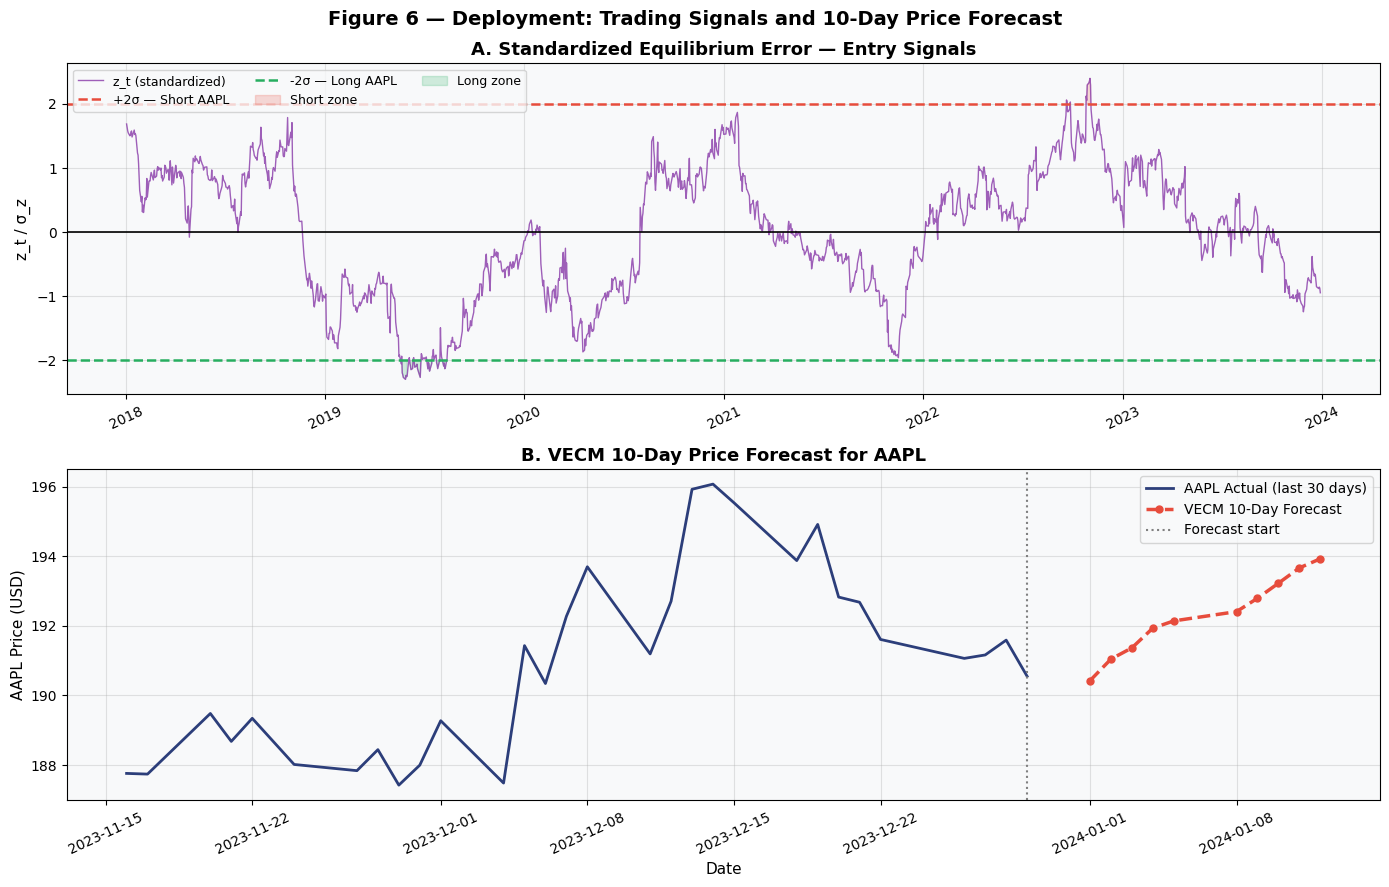

In [ ]:
# Figure 6: Deployment — signal chart and VECM forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Figure 6 — Deployment: Trading Signals and 10-Day Price Forecast',
             fontsize=14, fontweight='bold')

# Panel A: standardized z_t with entry and exit signals highlighted
ax = axes[0]
ax.plot(signal_df.index, signal_df['z_std'], color=PURPLE, lw=1.0, alpha=0.85, label='z_t (standardized)')
ax.axhline(0,  color='black', ls='-', lw=1.2)
ax.axhline( 2, color=RED,   ls='--', lw=1.8, label='+2σ — Short AAPL')
ax.axhline(-2, color=GREEN, ls='--', lw=1.8, label='-2σ — Long AAPL')
ax.fill_between(signal_df.index, 2, signal_df['z_std'],
                where=(signal_df['z_std'] > 2), color=RED, alpha=0.2, label='Short zone')
ax.fill_between(signal_df.index, -2, signal_df['z_std'],
                where=(signal_df['z_std'] < -2), color=GREEN, alpha=0.2, label='Long zone')
ax.set_title('A. Standardized Equilibrium Error — Entry Signals')
ax.set_ylabel('z_t / σ_z')
ax.legend(fontsize=9, ncol=3)
ax.tick_params(axis='x', rotation=25)

# Panel B: actual AAPL prices vs VECM 10-day forecast
actual  = raw['AAPL'].iloc[-30:]
fc_idx  = pd.date_range(start=raw.index[-1], periods=HORIZON+1, freq='B')[1:]
axes[1].plot(actual.index, actual, color=BLUE, lw=2, label='AAPL Actual (last 30 days)')
axes[1].plot(fc_idx, fc_prices['AAPL_forecast'], color=RED,
             lw=2.5, ls='--', marker='o', markersize=5, label='VECM 10-Day Forecast')
axes[1].axvline(raw.index[-1], color='gray', ls=':', lw=1.5, label='Forecast start')
axes[1].set_title('B. VECM 10-Day Price Forecast for AAPL')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('AAPL Price (USD)')
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('fig6_deployment.png', dpi=150, bbox_inches='tight')
plt.show()

\---
## 9. Conclusion
---

\Cointegration is a really useful tool for finding balance in financial markets and building trading strategies. By confirming that both AAPL and MSFT are $I(1)$ but share a stationary connection, we proved that there is a long-term pricing relationship between them. The VECM helps us measure exactly how they are linked (using $\boldsymbol{\beta}$) and how fast each stock "snaps back" to that average price after a market shock (using $\boldsymbol{\alpha}$).


The model is not perfect due to the fact that the residuals are non-normal, there are ARCH effects, and the cointegrating vector drifts over time. These are real limitations that we addressed in the Damage and Directions sections. In practice, the model would be re-adjusted quarterly, combined with a GARCH extension to handle time-varying volatility, and monitored continuously for structural breaks.

\
## References
---

Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Engle, Robert F., and Clive W. J. Granger. "Co-integration and Error Correction: Representation, Estimation, and Testing." *Econometrica*, vol. 55, no. 2, 1987, pp. 251–276.

Greene, William H. *Econometric Analysis*. 8th ed., Pearson, 2018.

Hamilton, James D. *Time Series Analysis*. Princeton University Press, 1994.

Johansen, Søren. "Statistical Analysis of Cointegration Vectors." *Journal of Economic Dynamics and Control*, vol. 12, 1988, pp. 231–254.

Lütkepohl, Helmut. *New Introduction to Multiple Time Series Analysis*. Springer, 2005.

Yahoo Finance. *Apple Inc. (AAPL) and Microsoft (MSFT) Historical Data*. finance.yahoo.com/quote/AAPL/history/. Accessed 2024.